# Introduction to the Finite Element Method (FEM)


The evolution of a physical quantity in time and space can usually be described in terms of partial differential equations (PDEs). But most of the time, such PDEs cannot be solved with analytical methods.
Various types of discretization and numerical methods can be employed to construct an approximation of the original problem, defined as a numerical model. The finite element method (FEM) is one way to compute such approximations.


## The Poisson equation

Let's start with a reference in the field of scientific computing : the heat equation, which models how a quantity such as heat (denoted as $u$) diffuses through a given region $\Omega$

$$\frac{\partial u}{\partial t} = \Delta u.$$

Here, $\Delta = \nabla^2 = \nabla \cdot \nabla$ is the *Laplace operator*, i.e., the divergence of the gradient of the scalar function $u$. 
For many applications we are interested in finding an equilibrium solution, where we have $\frac{\partial u}{\partial t} = 0$. In this case 
the equation simplifies to

$$\Delta u = 0 ,$$

which is called the Poisson equation. This equation is very useful in many applications, and also very popular as a first step when learning about the
finite element method. The concepts involved in solving the Poisson equation generalise very neatly to more complicated equations and higher dimensions.

To get a more intuitive understanding of the Poisson equation, and later of the methods we will use to solve it, we can consider a simple one-dimensional
version of the equation:
Imagine a 1D stick illustrated as the interval $[0, 1]$ being held at a fixed temperature $u(0)=0$ at one end, and $u(1)=1$ at the other. In 1D the Laplace operator 
simplifies to $\Delta u = \frac{\partial^2u} {\partial x^2}$, and we are left with the problem:

$$ \frac{\partial^2u} {\partial x^2} = 0 \qquad \text{with} ~~u(0)=0 ~\text{and}~ u(1)=1.$$

For brevity, we will in the following write derivatives with a subscript, so the second derivative with respect to $x$ is written as $u_{xx}$. With this
notation, the problem reads:

$$ u_{xx} = 0 \qquad \text{with} ~~u(0)=0 ~\text{and}~ u(1)=1.$$

This is a *boundary value problem* consisting of the PDE and two *boundary values* (at $x=0$ and $x=1$), which are needed to obtain a unique solution. The
boundary conditions used here are so-called *Dirichlet conditions*, where we specify the value of $u$ (the temperature) at the boundaries. Other commonly
used boundary conditions are *Neumann conditions*, where we specify the derivative $u_x$ (heat flux in our case), and *Robin conditions*, which use a linear
combination of the function value and its derivative. In our PDE the right-hand side is zero, which makes it a *homogeneous Poisson equation*, but it can 
easily be extended to include a non-zero function $f(x)$ or $f(u)$ on the right-hand side. 

Our simple 1D Poisson problem is easy to solve by hand, and we find that the solution is $u=x$. Applying the finite element method to solve
this problem is therefore not really needed, but it is always useful to solve a problem with a known analytical solution in order to
very the numerical solver. We will proceed to explain the main steps of the finite element method, both for our simple 1D model problem and for more general cases.

### Step 1 - The mesh

Before jumping into the mathematical details, let's start with the finite element discretization. Despite the enormous progress in terms of computer power, computers are still limited to solving a finite number of equations. We therefore need to represent the solution of our PDE problem by a finite number of parameters, i.e.,  
to *discretize* our problem in space (discretization of our domain $\Omega$) (and in time if we consider time dependent problems). 
The discretization in space consists in the subdivision of $\Omega$ into a (finite) set of "bricks" which we call a _mesh_.![meshes.png](fig/meshes.png)

For our simple 1D case we can easily discretize the interval domain $\Omega = [0,1]$ by choosing $N = 6$ points $[x_1, \dots, x_{N}]$ distributed uniformly in the domain, of which the first point is $x_1=0$ and the last point is $x_6=1$. The _mesh_ then consists in the 5 intervals that comes out of this.
We denote the distance between two adjacent mesh points by $h=\frac 1 {N-1}$. The points of the discretization are called the *nodes*, and
two nodes and the interval between them make up an *element*. 

### Step 2 - Representing the solution on the mesh

We need to approximate the solution $u$ using the mesh we defined in Step 1. In the Finite Element (FE) method we do this by defining a set of _basis functions_ $\{ \phi_i \}_{i=1}^{N}$, and express
our approximate solution $u_h$ as a linear combination of these:

$$ u_h = \sum \limits_{i=1}^{\mathcal{N}} u_i \phi_i $$

The basis functions $\phi_i$ will typically be defined as piecewise polynomials on the discretized domain (the mesh). For the one dimensional domain defined above, example 
basis functions can look like:
![fe_mesh1D_phi_2_3.png](fig/fe_mesh1D_phi_2_3.png)


These are the so called linear Lagrange elements (*P1 elements*), defined as piecewise linear functions satisfying $\phi_i = 1$ in node $i$ and $\phi_i = 0$ in all other nodes.
The elements of the mesh are labeled as $\Omega^{(0)}, \Omega^{(1)}, \ldots $ The one-dimensional P1 elements used here have two *degrees of freedom* per element.

If we use higher order polynomials we can construct more accurate approximate solutions, but we also 
get more degrees of freedom per element. P1 and P2 elements in 1D, 2D and 3D are illustrated below:

![Lagrange_p1_p2.png](fig/lagrange_p1_p2.png)

A large variety of finite elements and their basis functions are shown at [DefElement](https://defelement.com/), a finite element encyclopedia by Matthew W. Scroggs.

The Python code below plots the basis functions for our discretized 1D domain, producing essentially the same plot as shown above. 

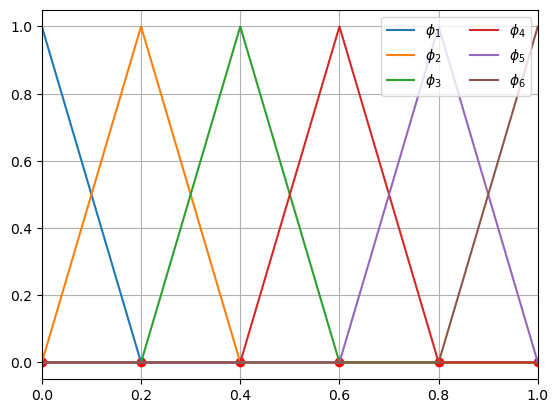

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

N = 6
x = np.linspace(0, 1, N)


def phi(i):
    y = np.zeros(N)
    y[i] = 1.0
    return y


plt.plot(x, np.zeros_like(x), "ro")

for i in range(N):
    plt.plot(x, phi(i), label=rf"$\phi_{i + 1}$")

plt.xlim(0, 1)
plt.grid()
plt.legend(ncol=2, loc="upper right")

Plotting the derivative of the basis functions, here exemplified with $\phi_4$, illustrates that it is not very useful to compute their second derivative, as it will be zero everywhere except at the nodes, where it is undefined. 

(0.0, 1.0)

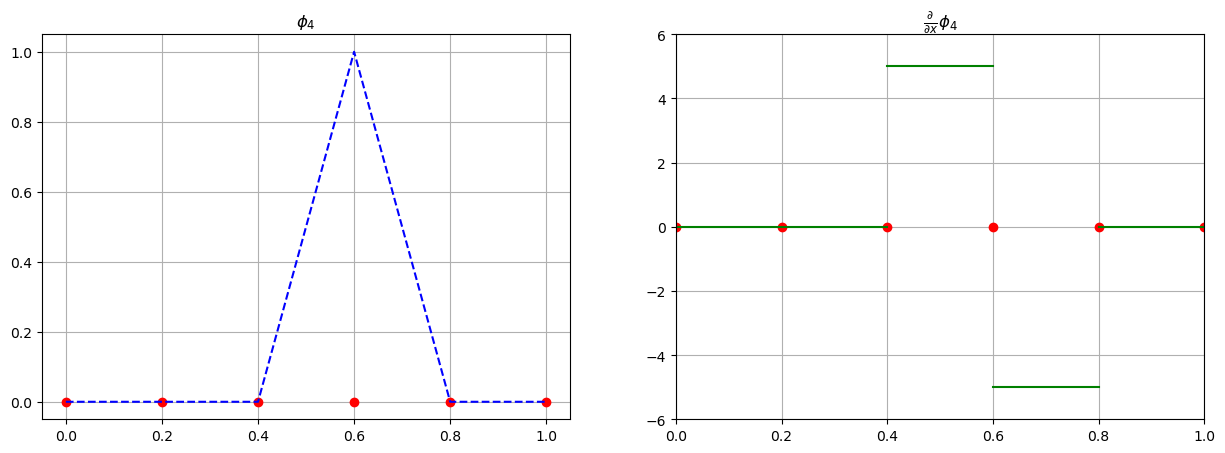

In [2]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
i = 3
h = 1 / (N - 1)
ax1.set_title(rf"$\phi_{i + 1}$")

ax1.plot(x, np.zeros(N), "ro")
ax1.plot(x, phi(i), "b--")
ax1.grid()

ax2.set_title(r"$\frac{\partial}{\partial x}$" + rf"$\phi_{i + 1}$")

ax2.plot(x, N * [0], "ro")
ax2.grid()
x1, x2 = x[:i], x[(i + 1) :]
ax2.plot(x1, [0] * x1.shape[0], "g-")
ax2.plot(x2, [0] * x2.shape[0], "g-")
ax2.plot([x[i - 1], x[i]], [1 / h, 1 / h], "g-")
ax2.plot([x[i], x[i + 1]], [-1 / h, -1 / h], "g-")

ax2.set_ylim(-N, N)
ax2.set_xlim(0, 1)

_Terminology:_ In finite element literature and software you will often see the term *function space*. This concept is extremely useful for the theoretical foundation
of the finite element method, but using the method does not require a deep understanding of function spaces. In short, we define a function space $X(\Omega)$  as all the functions defined on $\Omega$ that satisfy certain properties. For instance, a commonly used function space is $L_2$, which is the space of square integrable functions, i.e., all
functions $f$ that satisfy:
$$
\int_\Omega | f(x) | ^2 dx < \infty
$$
This is an infinite-dimensional space, which is not suitable for use in computational methods. In general, if we assume that our solution $u$ belongs to a function
space $X(\Omega)$, we solve the problem by defining a finite-dimensional space $X_{h}(\Omega)$, which is a *subspace* of $X(\Omega)$, and select the basis functions 
$\phi_i$ so that they span the space $X_{h}(\Omega)$.


__The fundamental idea of the finite element method is to insert the approximate solution $u_N$ into our PDE, and determine the unknown coefficients $u_i$ so that the equation
is satisfied. However, we need to take a couple more steps before we get to this.__

### Step 3 - The weak form

If we try to insert the approximate solution $u_h$ into the Poisson equation defined above, we immediately run into a problem. We need to compute the double derivative
$u_{xx}$ in every point, which is not possible for a non-smooth, piecewise linear function (as illustrated by the plots above). 
In the FE method we bypass this problem by reformulating
the PDE into an equivalent form called the _weak form_. The solution of the weak form is called the _weak solution_, while the original PDE is called the _strong form_, and its solution $u$ the _strong solution_.

The weak form of a PDE is obtained by multiplying the strong form by an arbitrary function $v$ called a _test function_, integrating both sides of the equation over
the domain $\Omega$, and requiring that the resulting equation is satisfied for *all* choices of $v$. For the simple 1D-version of the Poisson equation, we get
$$
\int_0^1 u_{xx} v dx = 0 ,
$$
which should be satisfied for all $v$ $in a chosen function space. We will typically choose the same function space for the test functions
as for the solution to $u$ (giving the so-called *Galerkin* method).
Note that we always multiply and integrate both sides of the equation, but in this case it simplifies because the right-hand side is zero. 

We can apply integration by parts to left-hand side, which gives
$$
\int_0^1 u_{xx} v dx = [ u_x v]_0^1 - \int_0^1 u_x v_x dx ,
$$
and the weak form of our 1D problem becomes:

Find $u \in X(\Omega)$ such that
$$
\int_0^1 u_x v_x dx = [ u_x v]_0^1 ~\forall v \in X(\Omega) .
$$
(Note that in this case we have $\Omega = [0,1]$, but we write $X(\Omega)$ since $X([0,1])$ looks a bit strange.)

Comments about the weak form:
* The weak form only involves first-order derivatives, ($u_x, v_x$). It therefore has weaker restrictions on the *smoothness* of the solution
  than the corresponding strong form of the equation.
* It is easy to show that a function $u$ which satisfies the strong form of the equations also solves the weak form. 
* A weak solution that is sufficiently smooth is also a solution of the strong form. 
* The right-hand side term provides a convenient way to handle boundary conditions. More on this later. 


In general, the weak form a PDE will look like this:

Find $u \in X(\Omega)$ such that

$$a(u,v) = f(v) ~\forall v \in X(\Omega)$$

where $a$ and $f$ are a _bilinear_ and a _linear_ form, respectively, and $X(\Omega)$ is a given function space. Such a weak formulation is the foundation of the 
finite element method, and finite element software usually requires the user to implement the weak form in one form or another. In FEniCS we shall see that the 
implementation of the form is very similar to the mathematics. 

For the 1D Poisson problem, we have
$$
a(u,v) = [ u_x v]_0^1 -  \int_0^1 u_x v_x dx , \\
b(v) = 0
$$
while for the more general 2D/3D version of the Poisson problem we have 
$$
a(u,v) =  \int_{\delta \Omega} (\nabla u \cdot n) v
- \int_{\Omega} \nabla u \cdot \nabla v,  \\
b(v) = 0
$$
Here $\delta \Omega$ is the boundary of $\Omega$, $n$ is the outward normal of $\delta \Omega$, and the surface integral arises from applying Green's theorem, 
which is essentially a multi-dimensional version of integration by parts. 


#### Two notes on boundary conditions
For our 1D proble we have defined Dirichlet boundary conditions, where we know the values $u(0)$ and $u(1)$. Such boundary conditions are often called
*essential boundary conditions*, and need to be enforced explicitly 
in the solution. Mathematically, we say that we modify the function space for $u$ so that the solution is forced to satisfy the boundary conditions. 
When implementing the solver there are tools in FEniCS to handle this, which we will describe later. 

As noted above, another very common type of boundary conditions are the Neumann conditions, where we know the value of the solutions first derivative, i.e. $u_x$ in the
1D case or $\nabla u \cdot n$ in 2D or 3D. Such boundary conditions are very conveniently handled in the FE method, and are often reffered to as *natural* boundary 
conditions. The simplest case is if we have $u_x = 0$ (or $\nabla u \cdot n = 0$ in 2D/3D). In this case the boundary terms will simply vanish, and we 
enforce boundary condition by not implementing these terms at all! If we instead have a condition $\nabla u \cdot n = q$, for some non-zero $q$, the surface integral must 
be included, but simplifies considerably since it no longer involves the unknown $u$.

### Step 4: The discretized weak form

As noted above, we approximate the solution $u$ as
$$ u_h = \sum \limits_{i=1}^{N} u_i \phi_i, $$
where $\phi_i$ are the basis functions for our solution space $X(\Omega)$. 

For the Lagrangian elements we use here, the coefficients $u_i$ in the approximation

$$ u_h = \sum \limits_{i=1}^{N} u_i \phi_i $$

are in fact the nodal values of the approximate solution, as illustrated below.

![FEM_intro1.png](fig/FEM_intro1.png)

As noted above, we focus on the *Galerkin* class of methods, where the same function space $X(\Omega)$ is used for the solution $u$ and the test functions $v$. Since the 
basis functions $\phi_i$ form a basis for the space $X(\Omega)$, all test functions $v$ can be realized as linear combinations of these test functions. The weak 
formulation above can therefore be written as:

Find $u_h \in X_h(\Omega)$ such that
$$a(u_h,\phi_j) = f(\phi_j) ~ for j = 1, \ldots N $$

We now insert the approximation $u_h = u_N = \sum \limits_{i=1}^{N} u_i \phi_i $ into this weak form, to get:

$$a(\sum_{i=1}^N u_i \phi_i,\phi_j) = f(\phi_j) \quad \text{for} j = 1, \ldots N.$$

Now, since the form $a(\cdot, \cdot)$ is bilinear, we can pull the sum and the coefficients $u_i$ outside out of the form. This gives

$$ \sum_{i=1}^N a(\phi_i,\phi_j) u_i = f(\phi_j) \quad \text{for} j = 1, \ldots N.$$

This is a linear system of equations for the unknowns $u_i$, which can be written on matrix form as

$$
A u = b ,
$$
with
$$ A_{ij} = a(\phi_i, \phi_j) \quad \text{and } \quad b_j = f(\phi_j) . $$
Recall that the basis functions $\phi_i$ are known, so computing the matrix $A$ and the vector $b$ simply involves evaluating the bilinear and linear forms for all these
functions. 

To get a more intuitive understanding of how we get to the discretized linear system, let us return to the specific example of our 1D Poisson equation. 
In this case we have 
$$
a(\phi_i, \phi_j) = [ (\phi_i)_x \phi_j]_0^1 -  \int_0^1 (\phi_i)_x (\phi_j)_x dx , \quad b(\phi_j) = 0 ,
$$
and we see that in order to compute the matrix $A$ of our linear system we need to compute the functions $\phi_i$ and their
derivatives, and integrate the resulting expressions over the interval $[0,1]$. This integration is a key step of the
finite element method, and it is implemented by performing the integration element by element and then
*assempbling* the contributions into the overall matrix $A$. The detailed implementation of the assembly process
is handled by FEniCS (or any other modern finite element framework) and we do not need to consider the details. It
is however, useful to be aware of a few key concepts:
* Recall from the definition of the basis functions above that basis function $\phi_i$ is non-zero only on the
  elements adjacent to node $i$, and otherwise zero. In practice this means that nearly all
  products $(\phi_i)_x (\phi_j)_x$ will be zero, except when we have $i = j, i = j-1$, or $i = j+1$, i.e., if $i,j$ are the
  same node or they are neighbors. This means that the matrix $A$ will be sparse, and in the 1D-case we only have three 
  non-zero entries per row, regardless of how many nodes we have. In 2D and 3D there will be a few more, since there are more neighboring
  nodes, but most of the entries in $A$ will still zero. This fact substantially speeds up the assembly process and
  the solution of the resulting linear system. 
* If we compute $A$ and $b$ for the 1D problem, using the formula above, we get a linear system
  $$
  Au = 0,
  $$
  which has the trivial solution $u=0$. This solution does not solve our original problem, since we required $u(0) = 0, u(1) = 1$. The
  reason for this discrepancy is that we have not yet enforced the Dirichlet boundary conditions in the problem. These need to 
  be incorporated directly in the linear system, by essentially deleting the rows in the system that correspond to boundary nodes 
  and replacing them with the boundary conditions. This process is handled semi-automatically by FEniCS and other FE software,
  and we only need to specify the boundary conditions. 

## Optional reading: Details of the assembly process
We really need to deal with the details of assembling and solving the linear system, since this is handled by FEniCS or other FE software. However, for understanding
how the methods work it may be useful to go through an example in more detail. The linear system resulting from the FE method, as introduced above, will look something 
like this: 
$$
 \underbrace{
 \begin{bmatrix}
    a(\phi_1, \phi_1) & \dots & \dots & \dots & a(\phi_N, \phi_1) \\[2.2pt]
    \vdots & \ddots & {} & {} & \vdots \\[2.2pt]
    \vdots & {} & a(\phi_j, \phi_j) & {} & \vdots \\[2.2pt]
    \vdots & {} & {} & \ddots & \vdots \\[2.2pt]
    a(\phi_1, \phi_N) & \dots & \dots & \dots & a(\phi_N, \phi_N)
\end{bmatrix}}_{\mathcal{A}_N(i,j) = a(\phi_j, \phi_i)}
\begin{bmatrix}
    u_1 \\[2.2pt]
    \vdots \\[2.2pt]
    u_j \\[2.2pt]
    \vdots \\[2.2pt]
    u_N
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
    f(\phi_1) \\[2.2pt]
    \vdots \\[2.2pt]
    f(\phi_j) \\[2.2pt]
    \vdots \\[2.2pt]
    f(\phi_N)
\end{bmatrix}}_{\mathcal{B}_N(j) = f(\phi_j)}
$$


Such a system is assembled element by element. For each element $K$ of the mesh we compute the corresponding local matrix $\mathcal A^K_N$, by integrating the relevant basis 
functions over that specific elements. The entries of this *element matrix* are then added in to the global matrix$\mathcal A_\mathcal{N}$, using the map between local and global 
node numbers. A graphical illustration of this process is given below. 

![solving.png](fig/solving.png)


If we now return to the simple 1D Poisson problem on $\Omega = [0,1]$, each element of the mesh is an interval $[x_i, x_{i+1}]$ with $1 \leqslant i <  N$.
The corresponding local element matrix is:

$$
 \begin{bmatrix}
 \displaystyle{
 \int \limits_{x_i}^{x_{i+1}} \frac{\partial \phi_i}{\partial x} \frac{\partial \phi_{i}}{\partial x}} &
 \displaystyle{
 \int \limits_{x_i}^{x_{i+1}} \frac{\partial \phi_{i+1}}{\partial x} \frac{\partial \phi_{i}}{\partial x}}\\
 \displaystyle{
  \int \limits_{x_i}^{x_{i+1}} \frac{\partial \phi_i}{\partial x} \frac{\partial \phi_{i+1}}{\partial x}} &
  \displaystyle{
 \int \limits_{x_i}^{x_{i+1}} \frac{\partial \phi_{i+1}}{\partial x} \frac{\partial \phi_{i+1}}{\partial x}} \\
 \end{bmatrix}
 =
 \begin{bmatrix}
 \displaystyle{\frac{1}{h}} & -\displaystyle{\frac{1}{h}} \\
 -\displaystyle{\frac{1}{h}} & \displaystyle{\frac{1}{h}} \\
 \end{bmatrix}
$$

The dimensions of the element matrix is $2 \times 2$ since we have two nodes for each element. Each of these local matrices is added to the global matrix $A_N$, 
using the mapping between the local node numbers (1 and 2) of an element to the global node numbers. After completing this process we end up with a tridiagonal matrix with
entries $2/h$ on the main diagonal and $-1/h$ on the lower and upper codiagonals. As noted above, the right-hand side $b$ of our linear system will at this stage be zero,
but the system needs to be modified to incorporate the boundary conditions. Note that in more complex and relevant cases it is usually not possible to evaluate the integrals
in the element matrix analytically, and they instead need to be approximated with numerical integration methods. 

 The Dirichlet boundary conditions $u(0) = 0$ and $u(1) = 1$ can be imposed directly in the linear system by simply deleting the rows corresponding to nodes 1 and $N$ 
 (the end nodes of the mesh), and replacing them with equations that force these nodal values to the specified value. Specifically, the
 relevant rows in the matrix are replaced by rows with 1 on the diagonal and otherwise zero, while the corresponding rows in $b$ are replaced by the relevant boundary value. We end up with the following system:
$$
\begin{bmatrix}
    1 & 0 & 0 & 0 & 0 & 0 \\
    -\frac 1 h & \frac 2h & - \frac 1h & 0 & 0 & 0\\
    0 & -\frac 1 h & \frac 2h & - \frac 1h & 0 & 0 \\
    0 & 0 & -\frac 1 h & \frac 2h & - \frac 1h & 0 \\
    0 & 0 & 0 & -\frac 1 h & \frac 2h & - \frac 1h \\
    0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}\begin{bmatrix}
    u_1 \\[2.2pt]
    u_2 \\[2.2pt]
    u_3 \\[2.2pt]
    u_4 \\[2.2pt]
    u_5 \\[2.2pt]
    u_6
\end{bmatrix} = \begin{bmatrix}
    0 \\[2.2pt]
    0 \\[2.2pt]
    0 \\[2.2pt]
    0 \\[2.2pt]
    0 \\[2.2pt]
    1
\end{bmatrix}
$$


Here we see clearly that each row in $A$ has only three non-zero entries, and this would be true even if $N$ was a much larger number than 6. As noted above, this sparsity comes from the fact that the $\phi_i$ are very 'local' functions. Though we will not go into details here, this locality is really what makes the finite element method so powerful, as a sparse system of equations is a lot easier to solve numerically than a dense one.


As noted above, for most applications of the FE method we do not have analytical expressions for the matrix entries, and we actually need to go through the steps 
of numerical integration and assembly to construct the matrix $A$ and the right-hand side $b$. However, in our simple 1D case we have computed the
entire matrix analytically, and we can just implement it in Python and solve it:

In [3]:
H = 1 / h
A = np.array(
    (
        [
            [1, 0, 0, 0, 0, 0],
            [-H, 2 * H, -H, 0, 0, 0],
            [0, -H, 2 * H, -H, 0, 0],
            [0, 0, -H, 2 * H, -H, 0],
            [0, 0, 0, -H, 2 * H, -H],
            [0, 0, 0, 0, 0, 1],
        ]
    )
)

b = np.array([0, 0, 0, 0, 0, 1])

u = np.linalg.solve(A, b)
print(f"{u=}")

u=array([3.44169138e-16, 2.00000000e-01, 4.00000000e-01, 6.00000000e-01,
       8.00000000e-01, 1.00000000e+00])


From the definition of $u_N$ as a linear combination of the basis functions $\{ \phi_i \}_{i=1}^N$, it can easily be plotted, showing we get the expected solution :


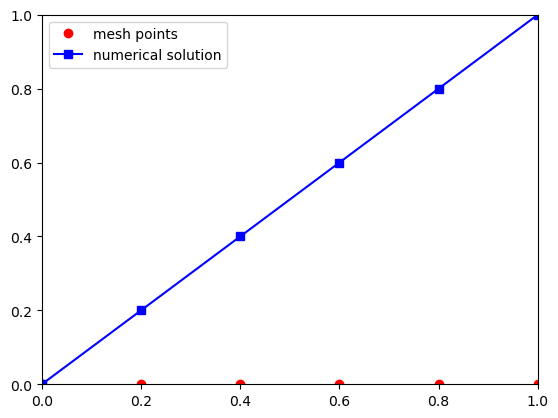

In [4]:
U = np.zeros(N)
for i in range(N):
    U += u[i] * phi(i)

plt.plot(x, [0] * N, "ro", label="mesh points")
plt.plot(x, U, "-bs", label="numerical solution")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()

We see that, as expected, the solution matches the analytical solution $u(x) = x$. 

# Summary

![summary.png](fig/summary.png)

The Finite Element Method can also be used to solve much more complicated PDEs, using more sophisticated basis functions $\phi_i$, on more complicated domains $\Omega$, etc... without significant deviations from the above procedure.
The next part will give examples of the method applied to more exciting equations and demonstrate how to use _FEniCS_, a popular open-source computing platform for solving partial differential equations.


# Exercises

```{exercise} Solve reaction diffusion with $n$ points
:label: l12-1
Repeat the procedure outlined here for the equation $u_{xx} + u = 0$. If you want, let the number of mesh points $n$ be arbitrary, otherwise just use 5. What does the system of equations look like?
```
Go to {ref}`solution <sol-l12-1>`.


```{exercise} Boundary conditions
:label: l12-2
The boundary condition $u=0$ at $x=0$ corresponds to fixing the temperature of the rod at the end $x=0$. What do you think the condition $u_x = 0$ would represent? Can it be incorporated into the system of equations somehow?
```
Go to {ref}`solution <sol-l12-2>`.



_Add your answer here_


## Exercise 2


_Add your answer here_


## Exercise 3

If we instead of having one equation with one unknown function had two equations with two unknown functions, could you still apply the finite element method? How?


_Add your answer here_


# Solutions

## Exercise 1


## Exercise 2


## Exercise 3


```{toggle}
Yes. Usually, if you have two unknowns $u_1, u_2$ and two equations $E_1, E_2$, you would introduce two test functions $v_1, v_2$, and multiply $E_1$ by $v_1$, $E_2$ by $v_2$ and integrate over the domain, leading to a formulation :
Find $$(u_1, u_2) \in X_1(\Omega) \times X_2(\Omega)$$ such that :
$$ a( (u_1, u_2), (v_1, v_2) ) = f(v_1, v_2) ~\forall (v_1, v_2) \in X_1(\Omega) \times X_2(\Omega)$$

As before, we use $u_1 = \sum_i u_{i,1} \phi_{i,1}$ and $u_2 = \sum_i u_{i,2} \phi_{i,2}$. Note that the function spaces $X_1(\Omega)$ and $X_2(\Omega)$ are not necessarily equal.
```
